In [1]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
#importing seaborn for statistical plots
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn import metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

### Read the input file and check the data dimension

In [2]:
ger_df= pd.read_csv('german_credit.csv')

In [3]:
ger_df.head()

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [4]:
ger_df.describe().T

,count,mean,std,min,25%,50%,75%,max
default,1000.0,0.300,0.458487,0.0,0.0,0.0,1.00,1.0
duration_in_month,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_as_income_perc,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
present_res_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
credits_this_bank,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
people_under_maintenance,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


In [5]:
ger_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [6]:
ger_df_names=pd.DataFrame(ger_df.dtypes,columns=['type'])
ger_df_names.head()

,type
default,int64
account_check_status,object
duration_in_month,int64
credit_history,object
purpose,object


In [7]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [8]:
test_size = 0.50 # taking 50:50 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
ger_df_1, ger_df_2= train_test_split(ger_df, test_size=test_size, random_state=seed)

In [9]:
# Lets build a Ensemble model but need to modify the dataset first
ger_df_1.shape
ger_df_2.shape

(500, 21)

(500, 21)

### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [10]:
obj_colnames=pd.DataFrame(ger_df_names.loc[ger_df_names['type']=='object'].T).columns
obj_colnames

int_colnames=pd.DataFrame(ger_df_names.loc[ger_df_names['type']=='int'].T).columns
int_colnames

Index(['account_check_status', 'credit_history', 'purpose', 'savings',
       'present_emp_since', 'personal_status_sex', 'other_debtors', 'property',
       'other_installment_plans', 'housing', 'job', 'telephone',
       'foreign_worker'],
      dtype='object')

Index(['default', 'duration_in_month', 'credit_amount',
       'installment_as_income_perc', 'present_res_since', 'age',
       'credits_this_bank', 'people_under_maintenance'],
      dtype='object')

In [11]:
ger_df_1_obj = pd.get_dummies(ger_df_1[obj_colnames])

ger_df_1_obj.head().T

,262,457,82,563,407
account_check_status_0 <= ... < 200 DM,0,0,0,1,0
account_check_status_< 0 DM,1,1,0,0,1
account_check_status_>= 200 DM / salary assignments for at least 1 year,0,0,0,0,0
account_check_status_no checking account,0,0,1,0,0
credit_history_all credits at this bank paid back duly,0,0,0,0,0
credit_history_critical account/ other credits existing (not at this bank),1,0,0,0,0
credit_history_delay in paying off in the past,0,0,0,0,0
credit_history_existing credits paid back duly till now,0,1,1,1,1
credit_history_no credits taken/ all credits paid back duly,0,0,0,0,0
purpose_(vacation - does not exist?),0,0,0,0,0


In [12]:
ger_df_1_new=pd.concat([ger_df_1_obj, ger_df_1[int_colnames]], axis=1)

In [13]:
# Print Shape of model data
ger_df_1_new.shape

(500, 62)

### Check for highly correlated variables but don't required any treatment for this use case

In [14]:
corr = ger_df_1_new.corr()
corr


,account_check_status_0 <= ... < 200 DM,account_check_status_< 0 DM,account_check_status_>= 200 DM / salary assignments for at least 1 year,account_check_status_no checking account,credit_history_all credits at this bank paid back duly,credit_history_critical account/ other credits existing (not at this bank),credit_history_delay in paying off in the past,credit_history_existing credits paid back duly till now,credit_history_no credits taken/ all credits paid back duly,purpose_(vacation - does not exist?),...,foreign_worker_no,foreign_worker_yes,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
account_check_status_0 <= ... < 200 DM,1.000000,-0.373070,-0.150809,-0.472983,-0.034180,-0.154005,0.058527,0.118514,0.016386,0.008223,...,-0.054576,0.054576,0.116593,0.114018,0.143620,-0.067434,-0.120421,-0.088513,-0.134189,-0.106872
account_check_status_< 0 DM,-0.373070,1.000000,-0.163512,-0.512824,0.129540,-0.050117,-0.093496,0.021173,0.051276,-0.007236,...,0.060026,-0.060026,0.245368,-0.020352,-0.056465,0.066033,0.099763,-0.003051,-0.008866,0.076662
account_check_status_>= 200 DM / salary assignments for at least 1 year,-0.150809,-0.163512,1.000000,-0.207303,0.014493,-0.041625,-0.046611,0.074927,-0.048233,0.066155,...,0.000377,-0.000377,-0.013116,-0.069055,-0.098673,-0.012067,-0.016563,0.053409,-0.101759,-0.028040
account_check_status_no checking account,-0.472983,-0.512824,-0.207303,1.000000,-0.096672,0.204537,0.057376,-0.162450,-0.038349,-0.033288,...,-0.007070,0.007070,-0.325050,-0.048893,-0.027248,0.004990,0.023275,0.055523,0.178287,0.038246
credit_history_all credits at this bank paid back duly,-0.034180,0.129540,0.014493,-0.096672,1.000000,-0.153324,-0.069998,-0.249707,-0.043939,0.037596,...,-0.042583,0.042583,0.132678,0.010133,-0.030963,0.123276,0.024278,0.007570,-0.111305,0.037889
credit_history_critical account/ other credits existing (not at this bank),-0.154005,-0.050117,-0.041625,0.204537,-0.153324,1.000000,-0.195658,-0.697982,-0.122818,-0.034047,...,0.029757,-0.029757,-0.179608,-0.072281,-0.043385,0.026525,0.102200,0.165262,0.540030,0.040665
credit_history_delay in paying off in the past,0.058527,-0.093496,-0.046611,0.057376,-0.069998,-0.195658,1.000000,-0.318653,-0.056071,0.078051,...,-0.054340,0.054340,0.001979,0.191216,0.166393,-0.074976,-0.043728,0.016991,0.088432,0.000582
credit_history_existing credits paid back duly till now,0.118514,0.021173,0.074927,-0.162450,-0.249707,-0.697982,-0.318653,1.000000,-0.200025,-0.013758,...,-0.011660,0.011660,0.064564,-0.096088,-0.105572,-0.010059,-0.082841,-0.178887,-0.518437,-0.055700
credit_history_no credits taken/ all credits paid back duly,0.016386,0.051276,-0.048233,-0.038349,-0.043939,-0.122818,-0.056071,-0.200025,1.000000,-0.040248,...,0.091296,-0.091296,0.110853,0.145428,0.186404,-0.076895,0.006119,0.039647,0.064361,0.003232
purpose_(vacation - does not exist?),0.008223,-0.007236,0.066155,-0.033288,0.037596,-0.034047,0.078051,-0.013758,-0.040248,1.000000,...,-0.039006,0.039006,0.149010,-0.012339,-0.002046,0.019732,0.055889,0.022546,-0.043540,0.058670


### Drop the original variables which are converted to dummy

In [15]:

ger_df_1_new.head()

,account_check_status_0 <= ... < 200 DM,account_check_status_< 0 DM,account_check_status_>= 200 DM / salary assignments for at least 1 year,account_check_status_no checking account,credit_history_all credits at this bank paid back duly,credit_history_critical account/ other credits existing (not at this bank),credit_history_delay in paying off in the past,credit_history_existing credits paid back duly till now,credit_history_no credits taken/ all credits paid back duly,purpose_(vacation - does not exist?),...,foreign_worker_no,foreign_worker_yes,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
262,0,1,0,0,0,1,0,0,0,0,...,0,1,0,18,5302,2,4,36,3,1
457,0,1,0,0,0,0,0,1,0,0,...,0,1,1,12,3386,3,4,35,1,1
82,0,0,0,1,0,0,0,1,0,0,...,0,1,0,18,1568,3,4,24,1,1
563,1,0,0,0,0,0,0,1,0,0,...,0,1,1,36,12389,1,4,37,1,1
407,0,1,0,0,0,0,0,1,0,0,...,1,0,0,15,1053,4,2,27,1,1


### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [16]:
#Split Target variable 

X = ger_df_1_new.drop("default", axis=1)
y = ger_df_1_new["default"]

test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, y, test_size=test_size, random_state=seed)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [17]:
Rf_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999)

Rf_model.fit(Xtrain,Ytrain)
Rf_model.score(Xtrain,Ytrain)




RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

1.0

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [18]:

ypred_dt=Rf_model.predict(Xtest)

print("********* Confusion Matrix **********")
metrics.confusion_matrix(Ytest,ypred_dt)

print("Accuracy score of Test data ",Rf_model.score(Xtest,Ytest) )

pd.DataFrame(data=[accuracy_score(Ytest, ypred_dt),recall_score(Ytest, ypred_dt),
                            precision_score(Ytest, ypred_dt),
                            f1_score(Ytest, ypred_dt)],
                      index=["accuracy", "recall", "precision", "f1_score"]).T

********* Confusion Matrix **********


array([[96,  7],
       [30, 17]])

Accuracy score of Test data  0.7533333333333333


,accuracy,recall,precision,f1_score
0,0.753333,0.361702,0.708333,0.478873


### Q6 Show the list of the features importance( 1 Marks)

In [19]:
print (pd.DataFrame(Rf_model.feature_importances_, columns = ["Imp"], index = Xtrain.columns))

                                                         Imp
account_check_status_0 <= ... < 200 DM              0.017320
account_check_status_< 0 DM                         0.025688
account_check_status_>= 200 DM / salary assignm...  0.008805
account_check_status_no checking account            0.056532
credit_history_all credits at this bank paid ba...  0.007715
credit_history_critical account/ other credits ...  0.016069
credit_history_delay in paying off in the past      0.009900
credit_history_existing credits paid back duly ...  0.013645
credit_history_no credits taken/ all credits pa...  0.007993
purpose_(vacation - does not exist?)                0.011673
purpose_business                                    0.010682
purpose_car (new)                                   0.013782
purpose_car (used)                                  0.010261
purpose_domestic appliances                         0.013564
purpose_education                                   0.003285
purpose_furniture/equipm

### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [20]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [21]:
# Use below values
num_folds = 10
seed = 77
kf=KFold(n_splits=num_folds,shuffle=True,random_state=seed)
#print("Cross_Validated_rmse_score: %0.03f (+/- %0.5f) [%s]" % (np.mean(rmse),np.var(rmse,ddof=1),name))   

kf

KFold(n_splits=10, random_state=77, shuffle=True)

In [22]:
#Validate the Random Forest model build above using k fold

In [23]:
scores=[]
for train,test in kf.split(X,y):
    Xtrain,Xtest=X.iloc[train,:],X.iloc[test,:]
    Ytrain,Ytest=y.iloc[train],y.iloc[test]
    Rf_model.fit(Xtrain,Ytrain)
    Y_predict=Rf_model.predict(Xtest)
    metrics.confusion_matrix(Ytest,Y_predict)
    scores.append(accuracy_score(Ytest,Y_predict))

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

array([[32,  3],
       [11,  4]])

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

array([[32,  3],
       [12,  3]])

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

...

array([[28,  6],
       [ 8,  8]])

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

array([[28,  5],
       [ 7, 10]])

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

array([[27,  4],
       [16,  3]])

In [24]:
#Calculate Mean score

In [25]:
np.mean(scores)

0.718

In [26]:
# Calculate score standard deviation using std()

In [27]:
np.std(scores)

0.0554616984954482

# Q8 Print the confusion matrix( 1 Marks)

In [28]:
Rf_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999)

Rf_model.fit(Xtrain,Ytrain)
Rf_model.score(Xtrain,Ytrain)



ypred_dt=Rf_model.predict(Xtest)

print("********* Confusion Matrix **********")
metrics.confusion_matrix(Ytest,ypred_dt)


RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

1.0

********* Confusion Matrix **********


array([[27,  4],
       [16,  3]])

# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [29]:

print("Accuracy score of Test data ",Rf_model.score(Xtest,Ytest) )

pd.DataFrame(data=[accuracy_score(Ytest, ypred_dt),recall_score(Ytest, ypred_dt),
                            precision_score(Ytest, ypred_dt),
                            f1_score(Ytest, ypred_dt)],
                      index=["accuracy", "recall", "precision", "f1_score"]).T

Accuracy score of Test data  0.6


,accuracy,recall,precision,f1_score
0,0.6,0.157895,0.428571,0.230769


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [30]:
#Hint: Use roc_curve

In [31]:
from sklearn.metrics import roc_curve, auc

y_predictProb = Rf_model.predict_proba(Xtest)

fpr, tpr, thresholds = roc_curve(Ytest, y_predictProb[::,1])

thresholds


array([1.662, 0.662, 0.624, 0.584, 0.528, 0.466, 0.43 , 0.384, 0.358,
       0.316, 0.314, 0.312, 0.302, 0.29 , 0.274, 0.268, 0.256, 0.24 ,
       0.234, 0.204, 0.202, 0.078, 0.054, 0.016])

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

In [32]:
roc_auc = auc(fpr, tpr)
roc_auc

0.8149405772495756

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'Receiver operating characteristic')

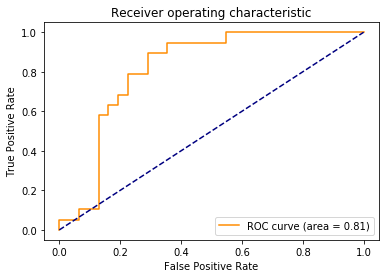

In [33]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [34]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [36]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(Xtrain, Ytrain)
    Rf_model.fit(X_, y_)
    y_pred = Rf_model.predict(Xtest)
    
    acc = accuracy_score(y_pred, Ytest)
    accuracy.append(acc)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

In [37]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.67
Standard deviation:  0.02569046515733025
